In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
ATSE_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/tabula_senis_test_intron_clusters_50_500000_10_20240927_single_cell.gz"
ATSE = pd.read_csv(ATSE_file, sep="}")

In [7]:
ATSE.head()

,junction_id,num_cells_with_junc,total_read_counts,total_5ss_counts,total_3ss_counts,5SS_usage,3SS_usage,Cluster,gene_id,gene_name,Count
0,chr1_9563871_9619549_-,1023,66262,67766,85017,0.977806,0.779397,3677,ENSMUSG00000079671.8,2610203C22Rik,5
1,chr1_9619639_9620954_-,1634,101426,102401,101426,0.990479,1.000000,3677,ENSMUSG00000079671.8,2610203C22Rik,5
2,chr1_9621082_9631060_-,1389,79841,79841,82320,1.000000,0.969886,3677,ENSMUSG00000079671.8,2610203C22Rik,5
3,chr1_10138996_10140466_-,2212,46397,47786,46397,0.970933,1.000000,3590,ENSMUSG00000067851.11,Arfgef1,3
4,chr1_10140584_10141558_-,1936,36935,36935,38324,1.000000,0.963756,3590,ENSMUSG00000067851.11,Arfgef1,3


In [ ]:
# 1. Distribution of junctions in clusters (how many junctions are in each cluster --> Count column)
# 2. Distribution of clusters and junctions in genes (how many Clusters and Junctions are found in each gene)
# 3. Distribution of total read counts across junctions as well as number of cells with each junction 

In [8]:
num_juncs_in_clust = ATSE[["Cluster", "Count"]].drop_duplicates()
num_juncs_in_clust

,Cluster,Count
0,3677,5
3,3590,3
5,2058,2
6,2059,3
8,1700,2
...,...,...
63471,42843,2
63476,48158,2
63514,56194,2
63548,46985,4


In [16]:
# Increase the font scale for seaborn
sns.set(font_scale=1.5)  # Adjust this value to increase or decrease font size
sns.set_style("white")  # Set the background to white

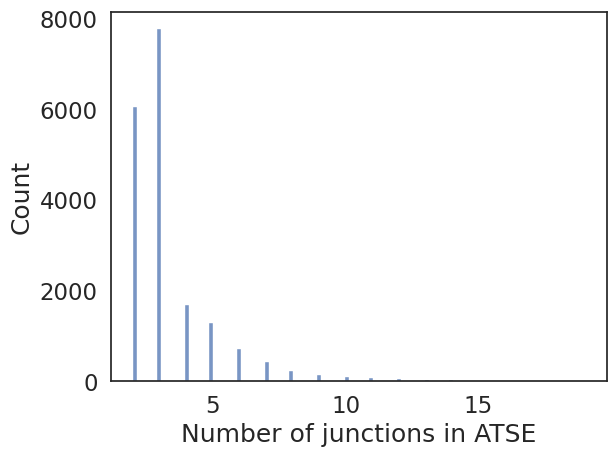

In [18]:
# Subset the data to only include rows where Count < 30
filtered_data = num_juncs_in_clust[num_juncs_in_clust["Count"] < 20]

# Plot the distribution for Count < 30
sns.histplot(data=filtered_data, x="Count", kde=False)
plt.xlabel("Number of junctions in ATSE")

# Show the plot
plt.show()

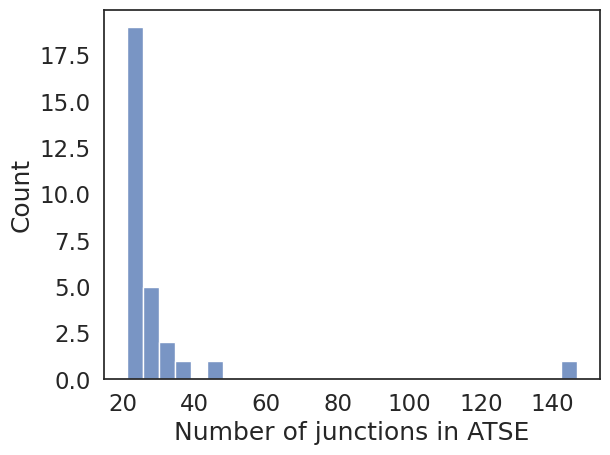

In [19]:
# Subset the data to only include rows where Count < 30
filtered_data = num_juncs_in_clust[num_juncs_in_clust["Count"] > 20]

# Plot the distribution for Count < 30
sns.histplot(data=filtered_data, x="Count", kde=False)
plt.xlabel("Number of junctions in ATSE")

# Show the plot
plt.show()

In [24]:
ATSE[ATSE["gene_id"] == "ENSMUSG00000051747.14"].Cluster.unique()

array([8424, 8445, 8446, 8447])

In [32]:
genes_per_cluster = pd.DataFrame(ATSE[["Cluster", "gene_id"]].drop_duplicates().value_counts("gene_id"))

In [33]:
genes_per_cluster

,count
gene_id,
ENSMUSG00000026131.18,13
ENSMUSG00000018501.17,12
ENSMUSG00000069601.14,10
ENSMUSG00000029478.16,10
ENSMUSG00000032826.17,10
...,...
ENSMUSG00000030780.15,1
ENSMUSG00000030775.10,1
ENSMUSG00000030772.6,1


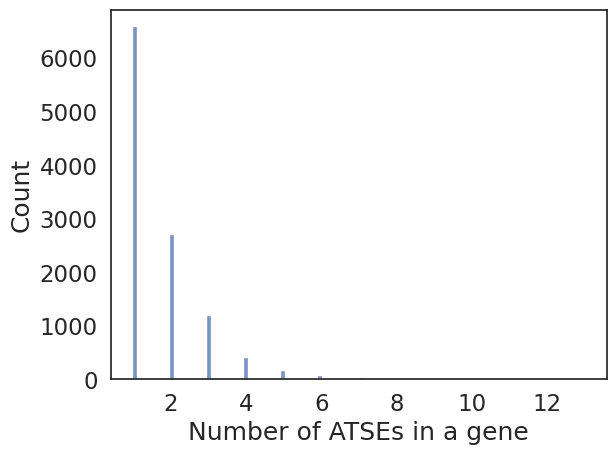

In [38]:
# Plot the distribution for Count < 30
sns.histplot(data=genes_per_cluster, x="count", kde=False)
plt.xlabel("Number of ATSEs in a gene")

# Show the plot
plt.show()

In [39]:
ATSE

,junction_id,num_cells_with_junc,total_read_counts,total_5ss_counts,total_3ss_counts,5SS_usage,3SS_usage,Cluster,gene_id,gene_name,Count
0,chr1_9563871_9619549_-,1023,66262,67766,85017,0.977806,0.779397,3677,ENSMUSG00000079671.8,2610203C22Rik,5
1,chr1_9619639_9620954_-,1634,101426,102401,101426,0.990479,1.000000,3677,ENSMUSG00000079671.8,2610203C22Rik,5
2,chr1_9621082_9631060_-,1389,79841,79841,82320,1.000000,0.969886,3677,ENSMUSG00000079671.8,2610203C22Rik,5
3,chr1_10138996_10140466_-,2212,46397,47786,46397,0.970933,1.000000,3590,ENSMUSG00000067851.11,Arfgef1,3
4,chr1_10140584_10141558_-,1936,36935,36935,38324,1.000000,0.963756,3590,ENSMUSG00000067851.11,Arfgef1,3
...,...,...,...,...,...,...,...,...,...,...,...
63567,chr4_41461672_41462374_-,5,94,94,94,1.000000,1.000000,14287,ENSMUSG00000028438.16,Kif24,6
63568,chr5_87813982_87815093_+,10,2382,2895,2382,0.822798,1.000000,17763,ENSMUSG00000061388.11,Csn1s2b,3
63569,chr5_87813982_87816640_+,5,513,2895,2696,0.177202,0.190282,17763,ENSMUSG00000061388.11,Csn1s2b,3
63570,chr5_87815126_87816640_+,10,2183,2183,2696,1.000000,0.809718,17763,ENSMUSG00000061388.11,Csn1s2b,3


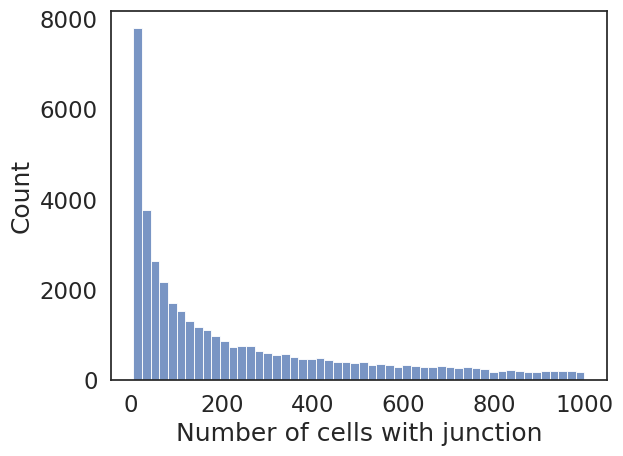

In [47]:
# Plot the distribution for Count < 30
filtered_data = ATSE[ATSE["num_cells_with_junc"] < 1000]
sns.histplot(data=filtered_data, x="num_cells_with_junc", kde=False)
plt.xlabel("Number of cells with junction")

# Show the plot
plt.show()

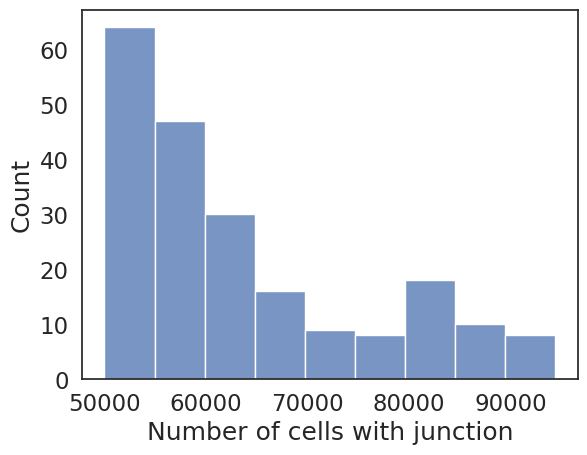

In [54]:
# Plot the distribution for Count < 30
filtered_data = ATSE[ATSE["num_cells_with_junc"] > 50000]
sns.histplot(data=filtered_data, x="num_cells_with_junc", kde=False)
plt.xlabel("Number of cells with junction")

# Show the plot
plt.show()

In [64]:
ATSE[ATSE["num_cells_with_junc"] > 90000].sort_values(by="num_cells_with_junc")

,junction_id,num_cells_with_junc,total_read_counts,total_5ss_counts,total_3ss_counts,5SS_usage,3SS_usage,Cluster,gene_id,gene_name,Count
2362,chr7_99480063_99481696_-,90169,40211644,40212188,41273970,0.999986,0.974262,26366,ENSMUSG00000030744.13,Rps3,3
2361,chr7_99479470_99479875_-,91406,50541362,50541600,50541362,0.999995,1.000000,26366,ENSMUSG00000030744.13,Rps3,3
1124,chr7_45122958_45123162_-,91908,27317435,27668483,27317435,0.987312,1.000000,25580,ENSMUSG00000003429.11,Rps11,2
1080,chr7_24885552_24888281_+,92289,34142580,34613231,34712257,0.986403,0.983589,24631,ENSMUSG00000040952.16,Rps19,3
139,chr10_128548973_128549087_-,94028,12698167,12698167,13720927,1.000000,0.925460,37724,ENSMUSG00000093674.7,Rpl41,2
1070,chr7_3705919_3706650_+,94388,32235711,32608203,32703377,0.988577,0.985700,23363,ENSMUSG00000006333.14,Rps9,2
